# CRM-таргет
Таргета `future_sessions_mean_playtime_7d` в данных нет, строю сама: для каждой сессии среднее по будущим сессиям этого же пользователя за 7 дней. Строки у которых окно выходит за край данных удаляю.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_parquet("/kaggle/input/datasets/vikakolganova/sesion/sessions_preprocessed (1).parquet")
for c in ["start", "end", "install_datetime", "prev_session_end", "session_date"]:
    if c in data.columns:
        data[c] = pd.to_datetime(data[c], errors="coerce")
print(data.shape)

(3438527, 84)


In [2]:
def buildcrm(data):
    data = data.sort_values(["appmetrica_device_id", "start"]).reset_index(drop=True)
    week = np.timedelta64(7, "D")
    last = data["start"].max()
    crm = np.full(len(data), np.nan)
    for dev, g in data.groupby("appmetrica_device_id", sort=False):
        s = g["start"].values
        d = g["duration_seconds"].values.astype(float)
        cs = np.concatenate([[0.0], np.cumsum(d)])
        idx = g.index.values
        for k in range(len(g)):
            lo = np.searchsorted(s, s[k], side="right")
            hi = np.searchsorted(s, s[k] + week, side="right")
            if hi > lo:
                crm[idx[k]] = (cs[hi] - cs[lo]) / (hi - lo)
    data["future_sessions_mean_playtime_7d"] = crm
    data = data[data["start"] + week <= last]
    data = data.dropna(subset=["future_sessions_mean_playtime_7d"]).reset_index(drop=True)
    return data

data = buildcrm(data)
print(data.shape)

(3071996, 85)


## Распределения таргетов

       target_next_session_length_sec  future_sessions_mean_playtime_7d
count                       3071996.0                         3071996.0
mean                            697.2                             645.1
std                            1552.0                             555.9
min                               1.0                               1.0
25%                              82.0                             296.5
50%                             310.0                             507.0
75%                             835.0                             822.7
max                           86400.0                            7858.0


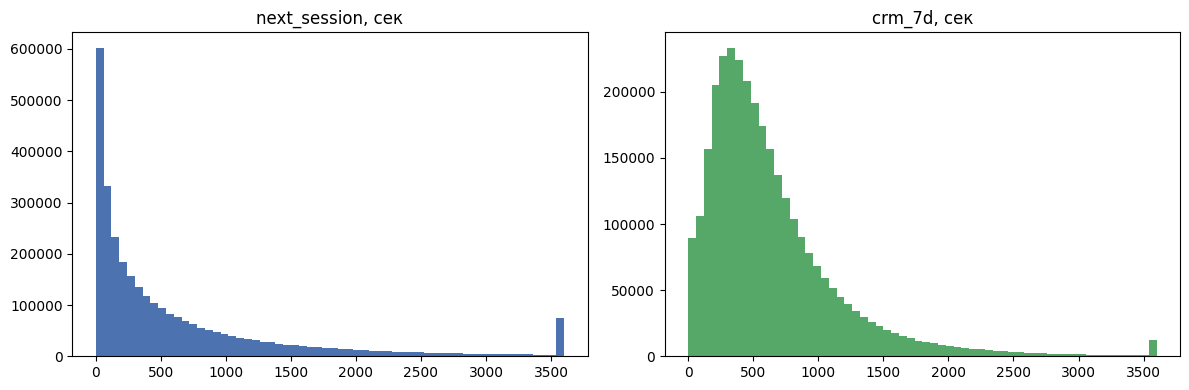

In [3]:
print(data[["target_next_session_length_sec", "future_sessions_mean_playtime_7d"]].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.clip(data["target_next_session_length_sec"], 0, 3600), bins=60, color="#4c72b0")
ax[0].set_title("next_session, сек")
ax[1].hist(np.clip(data["future_sessions_mean_playtime_7d"], 0, 3600), bins=60, color="#55a868")
ax[1].set_title("crm_7d, сек")
plt.tight_layout()
plt.show()

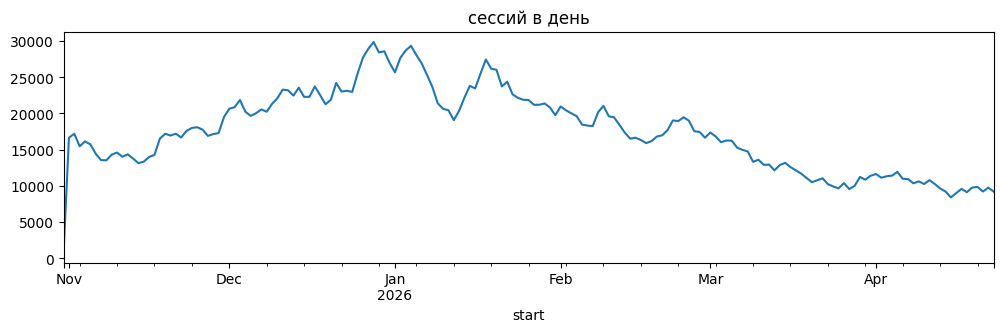

In [4]:
cnt = data.groupby(data["start"].dt.normalize()).size()
cnt.plot(figsize=(12, 3), title="сессий в день")
plt.show()

В логарифмической шкале распределения ближе к симметричным, поэтому модели учатся в шкале log1p_p995.

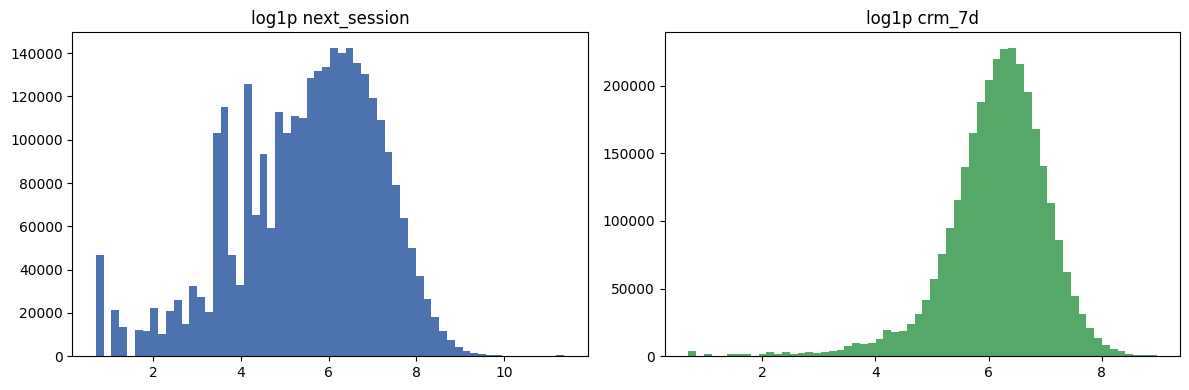

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.log1p(data["target_next_session_length_sec"]), bins=60, color="#4c72b0")
ax[0].set_title("log1p next_session")
ax[1].hist(np.log1p(data["future_sessions_mean_playtime_7d"]), bins=60, color="#55a868")
ax[1].set_title("log1p crm_7d")
plt.tight_layout()
plt.show()

## Связь таргетов
Как длина следующей сессии связана с недельным средним.

корреляция таргетов: 0.414


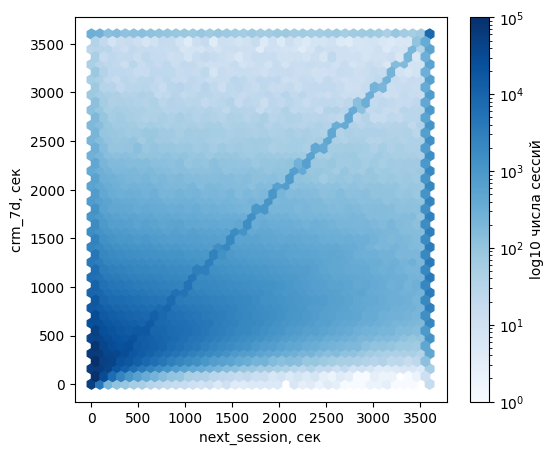

In [6]:
corr = data["target_next_session_length_sec"].corr(data["future_sessions_mean_playtime_7d"])
print("корреляция таргетов:", round(corr, 3))
plt.figure(figsize=(6, 5))
plt.hexbin(np.clip(data["target_next_session_length_sec"], 0, 3600),
           np.clip(data["future_sessions_mean_playtime_7d"], 0, 3600),
           gridsize=40, cmap="Blues", bins="log")
plt.xlabel("next_session, сек")
plt.ylabel("crm_7d, сек")
plt.colorbar(label="log10 числа сессий")
plt.show()

## Пользователи и сегменты

count    168023.0
mean         18.3
std          50.5
min           1.0
25%           2.0
50%           5.0
75%          15.0
max        4327.0
dtype: float64


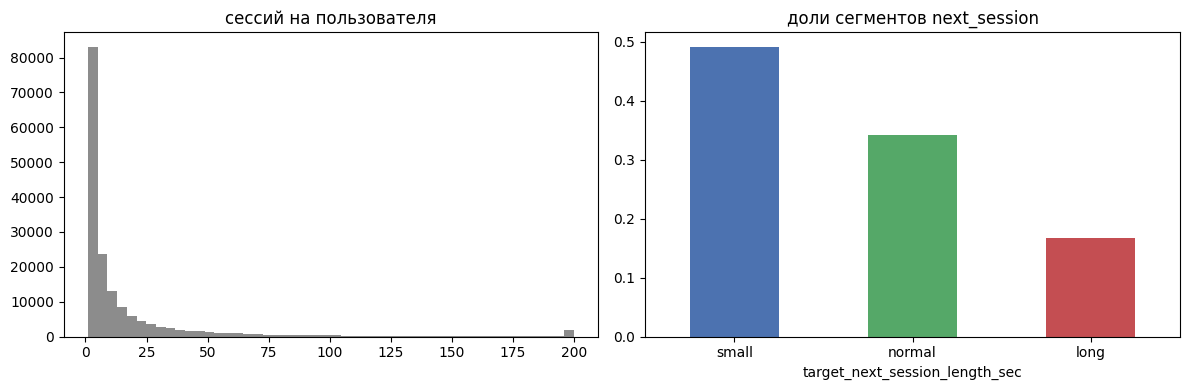

In [7]:
peruser = data.groupby("appmetrica_device_id").size()
print(peruser.describe().round(1))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.clip(peruser, 0, 200), bins=50, color="#8c8c8c")
ax[0].set_title("сессий на пользователя")
seg = pd.cut(data["target_next_session_length_sec"], [0, 300, 1200, np.inf], labels=["small", "normal", "long"])
seg.value_counts(normalize=True).reindex(["small", "normal", "long"]).plot.bar(ax=ax[1], color=["#4c72b0", "#55a868", "#c44e52"], rot=0)
ax[1].set_title("доли сегментов next_session")
plt.tight_layout()
plt.show()

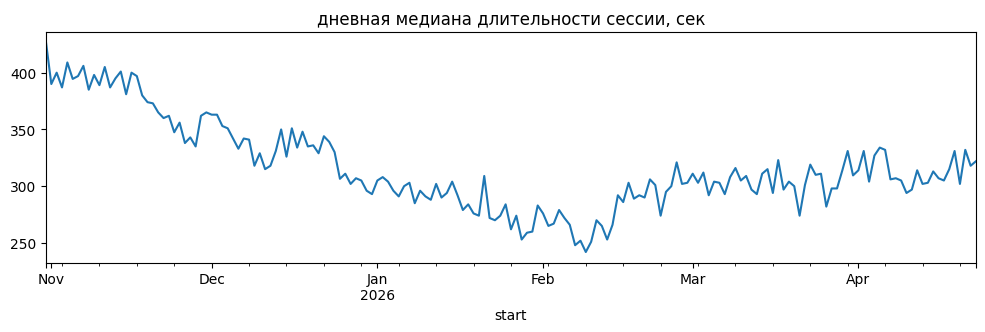

In [8]:
day = data.groupby(data["start"].dt.normalize())["duration_seconds"].median()
day.plot(figsize=(12, 3), title="дневная медиана длительности сессии, сек")
plt.show()

In [9]:
data.to_parquet("sessions_crm.parquet", index=False)